# Atividade de vendas no Brasil

## Entregável 1 - NumPy

In [ ]:
# Importanto bibliotecas

import pandas as pd
import numpy as np

In [2]:
# Leitura e carregamento do arquivo CSV

df = pd.read_csv('../../data/vendas_brasil_1.csv')
df.head()

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco
0,2022-04-13,4,Rio de Janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,...,10,5.2,6933.48,8.68,4.92,5.0,False,True,False,False
1,2023-03-12,3,Manaus,Site Web,Vestuário,Camiseta,Elisa Costa,Bronze,187.48,135.15,...,5,0.6,930.28,NaN,4.98,19.0,True,False,False,False
2,2022-09-28,9,Goiânia,App Mobile,Vestuário,Tênis,João Vieira,Bronze,76.11,61.40,...,14,0.7,1058.50,7.98,3.47,NaN,True,True,False,False
3,2022-04-17,4,Fortaleza,Site Web,Vestuário,Calça Jeans,Carla Mendes,Bronze,145.86,88.53,...,11,0.6,1592.43,20.49,4.50,16.0,False,True,False,False
4,2022-03-13,3,Belo Horizonte,App Mobile,Esportes,Bicicleta,João Vieira,Bronze,133.92,107.25,...,1,19.5,107.64,22.89,3.49,13.0,False,True,False,False


In [4]:
# Criando arrays

preco = df['preco_unitario'].values
custo = df['custo_unitario'].values
quantidade = df['quantidade'].values
desconto_pct = df['desconto_pct'].values
receita = df['receita_total'].values
frete = df['frete'].values

In [5]:
# Cálculo com operações vetorizadas

# 1. Valor bruto da venda (preço * quantidade)
valor_bruto = preco * quantidade

# 2. Valor do desconto 
valor_desconto = valor_bruto * (desconto_pct / 100)

# 3. Custo total (custo unitário * quantidade)
custo_total = custo * quantidade

# 4. Lucro estimado (receita total recebida - custo total)
lucro_estimado = receita - custo_total

# Resultados
print("Valor Bruto:", valor_bruto[:5])
print("Valor Desconto:", valor_desconto[:5])
print("Custo Total:", custo_total[:5])
print("Lucro Estimado:", lucro_estimado[:5])

Valor Bruto: [7393.9   937.4  1065.54 1604.46  133.92]
Valor Desconto: [384.4828    5.6244    7.45878   9.62676  26.1144 ]
Custo Total: [5617.5   675.75  859.6   973.83  107.25]
Lucro Estimado: [1.31598e+03 2.54530e+02 1.98900e+02 6.18600e+02 3.90000e-01]


In [ ]:
# Máscaras booleanas (Filtros no NumPy)

# 1. Vendas com receita acima da média
media_receita = receita.mean()
mascara_acima_media = receita > media_receita
qtd_acima_media = mascara_acima_media.sum() 

# 2. Vendas com prejuízo (lucro negativo)
mascara_prejuizo = lucro_estimado < 0
qtd_prejuizo = mascara_prejuizo.sum()

# 3. Vendas com desconto alto ( > 15%)
mascara_desconto_alto = desconto_pct > 15
qtd_desconto_alto = mascara_desconto_alto.sum()

print(f"Vendas acima da média: {qtd_acima_media}")
print(f"Vendas com prejuízo: {qtd_prejuizo}")
print(f"Vendas com desconto alto: {qtd_desconto_alto}\n")


# Agregações 

receita_media = receita.mean()
maior_receita = receita.max()
menor_receita = receita.min()
lucro_medio = lucro_estimado.mean()

print(f"1. Receita Média: R$ {receita_media:.2f}")
print(f"2. Maior Receita: R$ {maior_receita:.2f}")
print(f"3. Menor Receita: R$ {menor_receita:.2f}")
print(f"4. Lucro Médio: R$ {lucro_medio:.2f}")
print(f"5. Quantidade de vendas com prejuízo: {qtd_prejuizo}")

Vendas acima da média: 9236
Vendas com prejuízo: 2168
Vendas com desconto alto: 11640

1. Receita Média: R$ 1891.69
2. Maior Receita: R$ 58430.28
3. Menor Receita: R$ 3.70
4. Lucro Médio: R$ 513.19
5. Quantidade de vendas com prejuízo: 2168


### Conclusão

#### Analisando as agregações, observamos que a receita média por venda é de aproximadamente R$ 1.891,69, gerando um lucro médio positivo de R$ 513,19. No entanto, existe uma disparidade enorme entre a menor venda (R$ 3,70) e a maior (R$ 58.430,28), o que indica que algumas vendas isoladas de altíssimo valor puxam a média para cima. Além disso, chama a atenção o alto volume de vendas com descontos elevados (11.640 casos), o que provavelmente pode ser a causa direta das 2.168 vendas que fecharam no vermelho (com prejuízo).

## Entregável 2 - Pandas

In [8]:
# Exploração inicial do dataset

df.head()
df.info()
df.describe()
df.shape
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37617 entries, 0 to 37616
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   data_venda          37617 non-null  object 
 1   mes                 37617 non-null  int64  
 2   cidade              37617 non-null  object 
 3   canal_venda         37567 non-null  object 
 4   categoria           37617 non-null  object 
 5   produto             37617 non-null  object 
 6   vendedor            37577 non-null  object 
 7   fidelidade_cliente  37617 non-null  object 
 8   preco_unitario      37617 non-null  float64
 9   custo_unitario      37617 non-null  float64
 10  margem_pct          37535 non-null  float64
 11  quantidade          37617 non-null  int64  
 12  desconto_pct        37617 non-null  float64
 13  receita_total       37617 non-null  float64
 14  frete               35738 non-null  float64
 15  avaliacao_cliente   34662 non-null  float64
 16  praz

data_venda               0
mes                      0
cidade                   0
canal_venda             50
categoria                0
produto                  0
vendedor                40
fidelidade_cliente       0
preco_unitario           0
custo_unitario           0
margem_pct              82
quantidade               0
desconto_pct             0
receita_total            0
frete                 1879
avaliacao_cliente     2955
prazo_entrega_dias    1504
devolucao                0
entrega_no_prazo         0
alta_temporada           0
flag_outlier_preco       0
dtype: int64

### Respostas da Exploração Inicial:
### Quantas linhas e colunas existem? O dataset possui 37.617 linhas e 21 colunas.

### Existem dados faltantes? Sim. Existem valores nulos nas colunas: canal_venda (50), vendedor (40), margem_pct (82), frete (1.879)avaliacao_cliente (2.955) e prazo_entrega_dias (1.504).

### Quais colunas parecem numéricas? As que possuem formato numérico (int64 ou float64): mes, preco_unitario, custo_unitario, margem_pct, quantidade, desconto_pct, receita_total, frete, avaliacao_cliente e prazo_entrega_dias.

### Quais colunas parecem categóricas? As que possuem formato object (textos) ou bool (Verdadeiro/Falso): data_venda (que precisará ser convertida), cidade, canal_venda, categoria, produto, vendedor, fidelidade_cliente, devolucao, entrega_no_prazo, alta_temporada e flag_outlier_preco.

In [ ]:
# Limpeza e tratamento

# 1. Convertendo a coluna de data (avisando que o formato está misturado e o dia pode vir primeiro)
df['data_venda'] = pd.to_datetime(df['data_venda'], format='mixed', dayfirst=True)

# 2. Padronizando a coluna categórica (removendo espaços extras e deixando tudo em Maiúsculas)
df['categoria'] = df['categoria'].str.strip().str.upper()

# 3. Tratando dados faltantes de forma adequada
df['frete'] = df['frete'].fillna(0)
df['vendedor'] = df['vendedor'].fillna('Desconhecido')

# Resultado da limpeza
df[['data_venda', 'categoria', 'frete', 'vendedor']].head()

,data_venda,categoria,frete,vendedor
0,2022-04-13,ELETRÔNICOS,8.68,Bruno Souza
1,2023-03-12,VESTUÁRIO,0.00,Elisa Costa
2,2022-09-28,VESTUÁRIO,7.98,João Vieira
3,2022-04-17,VESTUÁRIO,20.49,Carla Mendes
4,2022-03-13,ESPORTES,22.89,João Vieira


### Decisões de Limpeza:
1. A coluna data_venda foi convertida para datetime para permitir filtragens e análises temporais.
2. A coluna categórica categoria foi padronizada com a remoção de espaços em branco duplos e conversão de todos os caracteres para letras maiúsculas, evitando que categorias iguais sejam lidas como diferentes pelo Pandas.
3. Para os dados faltantes , os valores nulos de frete foram substituídos por 0 (assumindo se tratar de vendas com frete grátis), e os registros sem vendedor preenchido foram classificados com a string "Desconhecido".

In [15]:
# Criação de novas colunas

# 1. Ano da venda 
df['ano_venda'] = df['data_venda'].dt.year

# 2. Lucro total da linha (Receita Total subtraída do Custo Total daquela venda)
df['lucro_total'] = df['receita_total'] - (df['custo_unitario'] * df['quantidade'])

# 3. Faixa de receita (USANDO APPLY E LAMBDA)
# Classifica como 'Alta' se a receita passar de 2000, e 'Normal' caso contrário
df['faixa_receita'] = df['receita_total'].apply(lambda x: 'Alta' if x > 2000 else 'Normal')

df[['data_venda', 'ano_venda', 'receita_total', 'lucro_total', 'faixa_receita']].head()

,data_venda,ano_venda,receita_total,lucro_total,faixa_receita
0,2022-04-13,2022,6933.48,1315.98,Alta
1,2023-03-12,2023,930.28,254.53,Normal
2,2022-09-28,2022,1058.50,198.90,Normal
3,2022-04-17,2022,1592.43,618.60,Normal
4,2022-03-13,2022,107.64,0.39,Normal


In [17]:
# Filtros

# 1. Quais vendas tiveram receita acima de R$ 5.000? 
filtro_receita = df[df['receita_total'] > 5000]
qtd_receita_alta = filtro_receita.shape[0]

# 2. Quais vendas tiveram devolução? 
filtro_devolucao = df[df['devolucao'] == True]
qtd_devolucoes = filtro_devolucao.shape[0]

# 3. Quais vendas pertencem à categoria de ELETRÔNICOS? 
filtro_eletronicos = df[df['categoria'] == 'ELETRÔNICOS']
qtd_eletronicos = filtro_eletronicos.shape[0]

# Resultado de um dos filtros 
filtro_receita[['data_venda', 'categoria', 'receita_total', 'devolucao']].head()

,data_venda,categoria,receita_total,devolucao
0,2022-04-13,ELETRÔNICOS,6933.48,False
15,2022-04-10,ELETRÔNICOS,7945.96,False
20,2022-12-10,ELETRÔNICOS,11246.38,False
21,2023-05-07,ELETRÔNICOS,6847.45,True
25,2022-10-04,ELETRÔNICOS,5065.74,False


### Aplicando os filtros na base de dados, descobrimos que 4004 vendas ultrapassaram a marca de R$ 5.000,00 em receita. Também identificamos um total de 3532 vendas que sofreram devolução, e que a categoria de Eletrônicos foi responsável por 7515 transações no período analisado.


In [18]:
# Agrupamentos com groupby

# 1. Qual categoria teve maior receita total?
receita_por_categoria = df.groupby('categoria')['receita_total'].sum().sort_values(ascending=False)
print("--- 1. Receita por Categoria (Top 3) ---")
print(receita_por_categoria.head(3), "\n")

# 2. Qual canal de venda teve maior quantidade de vendas (itens vendidos)?
vendas_por_canal = df.groupby('canal_venda')['quantidade'].sum().sort_values(ascending=False)
print("--- 2. Quantidade de vendas por canal (Top 3) ---")
print(vendas_por_canal.head(3), "\n")

# 3. Qual categoria teve maior lucro? 
lucro_por_categoria = df.groupby('categoria')['lucro_total'].sum().sort_values(ascending=False)
print("--- 3. Lucro total por Categoria (Top 3) ---")
print(lucro_por_categoria.head(3), "\n")

--- 1. Receita por Categoria (Top 3) ---
categoria
ELETRÔNICOS    45017479.88
ESPORTES       11567480.75
VESTUÁRIO       6780473.93
Name: receita_total, dtype: float64 

--- 2. Quantidade de vendas por canal (Top 3) ---
canal_venda
Site Web       84503
App Mobile     83188
Loja Física    56318
Name: quantidade, dtype: int64 

--- 3. Lucro total por Categoria (Top 3) ---
categoria
ELETRÔNICOS    12192275.55
ESPORTES        3133196.10
VESTUÁRIO       1849449.96
Name: lucro_total, dtype: float64 



In [19]:
# Merge (Tabela Auxiliar)

# 1. Criando a tabela auxiliar manualmente usando um dicionário
dados_regioes = {
    'cidade': ['Rio de Janeiro', 'Manaus', 'Goiânia', 'Fortaleza', 'Belo Horizonte'],
    'regiao': ['Sudeste', 'Norte', 'Centro-Oeste', 'Nordeste', 'Sudeste']
}
df_regioes = pd.DataFrame(dados_regioes)

# 2. Fazendo o merge (juntando a base principal com a nova tabela usando a 'cidade' como chave)
df_merged = pd.merge(df, df_regioes, on='cidade', how='left')

# 3. Análise simples com a nova coluna: Receita total por região
receita_por_regiao = df_merged.groupby('regiao')['receita_total'].sum().sort_values(ascending=False)

print("--- Receita Total por Região ---")
print(receita_por_regiao)

--- Receita Total por Região ---
regiao
Sudeste         13656325.61
Norte            7435641.08
Nordeste         7224144.20
Centro-Oeste     7137063.48
Name: receita_total, dtype: float64


### Nesta etapa de manipulação, estruturamos e limpamos uma base com mais de 37 mil registros. Tratamos dados nulos e formatos inconsistentes de data, o que nos permitiu criar colunas derivadas como a "Faixa de Receita" e o "Lucro Total". Através dos agrupamentos, identificamos as categorias e canais de maior impacto financeiro. O cruzamento final de tabelas (merge) adicionou uma camada geográfica aos dados.

# Entregável 3 - Seaborn

C:\Users\castr\AppData\Local\Temp\ipykernel_17892\4188269848.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='categoria', y='receita_total', data=receita_categoria, palette='viridis')


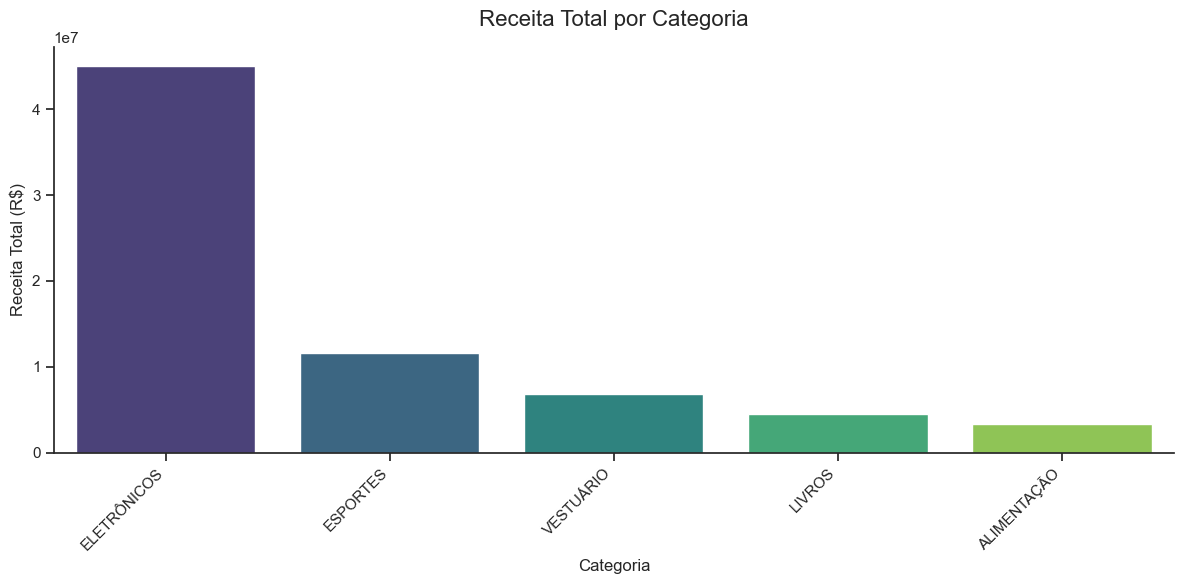

In [21]:
# Gráfico de barras - Receita por categoria

import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual padrão do Seaborn
sns.set_theme(style="ticks")

# 1. Preparando os dados
receita_categoria = df.groupby('categoria')['receita_total'].sum().sort_values(ascending=False).reset_index()

# 2. Criando o gráfico
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='categoria', y='receita_total', data=receita_categoria, palette='viridis')

# 3. Personalizações exigidas
plt.title('Receita Total por Categoria', fontsize=16, pad=15)
plt.xlabel('Categoria', fontsize=12)
plt.ylabel('Receita Total (R$)', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotacionando os rótulos para não embolar
sns.despine() # Removendo a borda superior e direita (exigência do professor)

plt.tight_layout()
plt.show()

### O gráfico de barras evidencia claramente quais categorias lideram o faturamento da empresa. A rotação dos eixos facilita a leitura, confirmando que os esforços de vendas e marketing devem continuar focados nas barras mais altas à esquerda para maximizar a receita.

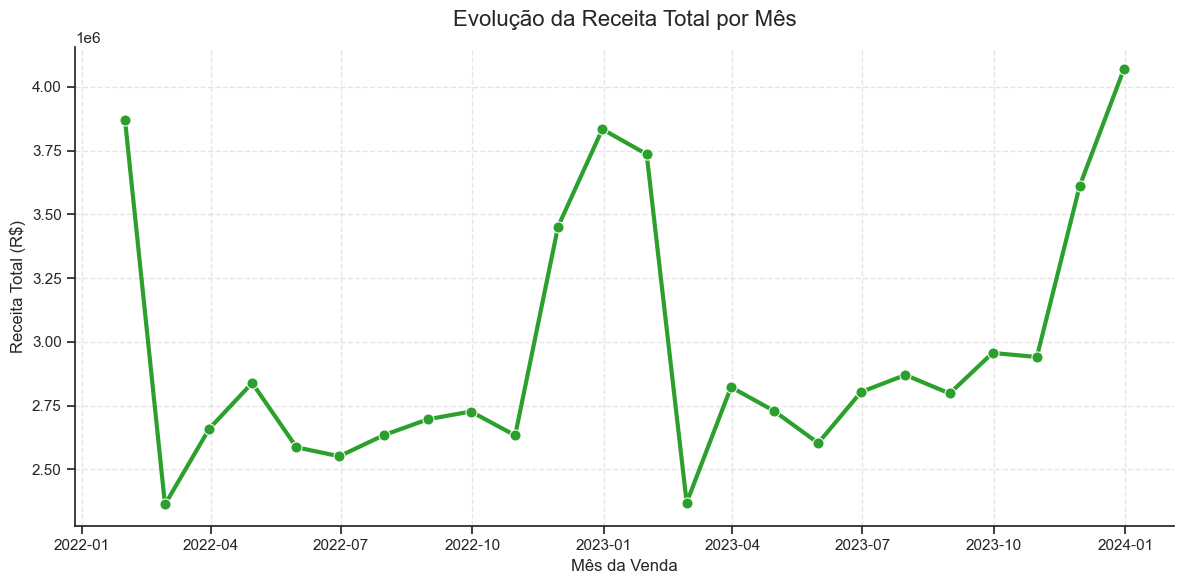

In [22]:
# Gráfico de Linha - Evolução no tempo

df_temporal = df.set_index('data_venda').resample('ME')['receita_total'].sum().reset_index()

# 2. Criando o gráfico
plt.figure(figsize=(12, 6))
sns.lineplot(x='data_venda', y='receita_total', data=df_temporal, 
             linewidth=3, color='#2ca02c', marker='o', markersize=8)

# 3. Personalizações
plt.title('Evolução da Receita Total por Mês', fontsize=16, pad=15)
plt.xlabel('Mês da Venda', fontsize=12)
plt.ylabel('Receita Total (R$)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
sns.despine()

plt.tight_layout()
plt.show()

### A linha do tempo demonstra o comportamento do faturamento mensal. O uso do agrupamento temporal (resample) revela os picos e vales de vendas, indicando os momentos de sazonalidade forte ao longo dos anos analisados.

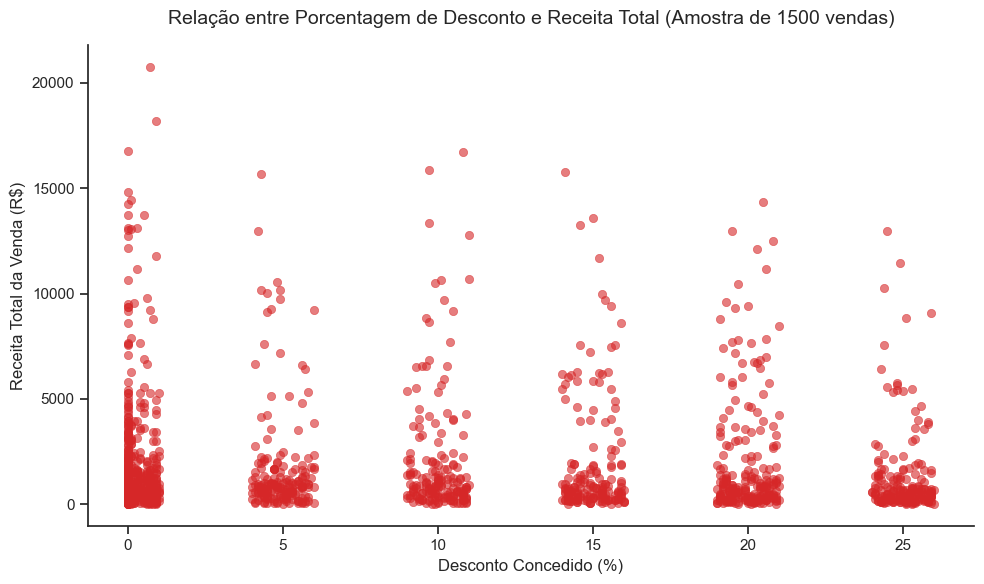

In [23]:
# Gráfico de Dispersão (Desconto vs. Receita)

df_amostra = df.sample(n=1500, random_state=42)

# 2. Criando o gráfico
plt.figure(figsize=(10, 6))
sns.scatterplot(x='desconto_pct', y='receita_total', data=df_amostra, 
                alpha=0.6, color='#d62728', edgecolor=None)

# 3. Personalizações
plt.title('Relação entre Porcentagem de Desconto e Receita Total (Amostra de 1500 vendas)', fontsize=14, pad=15)
plt.xlabel('Desconto Concedido (%)', fontsize=12)
plt.ylabel('Receita Total da Venda (R$)', fontsize=12)
sns.despine()

plt.tight_layout()
plt.show()

### A dispersão gerada a partir de uma amostra revela que conceder maiores percentuais de desconto não resulta obrigatoriamente em vendas de maior receita. A concentração de pontos sugere que os maiores valores faturados ocorrem frequentemente com descontos menores.

In [ ]:
# Mapa de calor

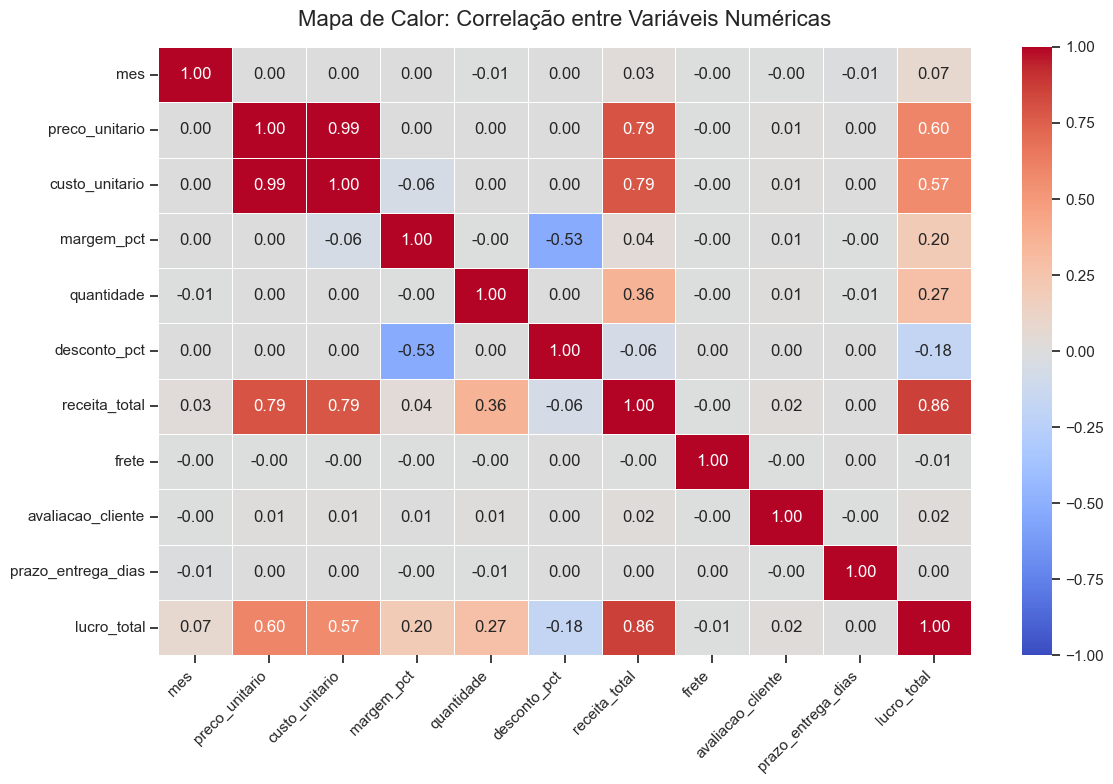

In [24]:

colunas_numericas = df.select_dtypes(include=['float64', 'int64']).columns
matriz_correlacao = df[colunas_numericas].corr()

# 2. Criando o gráfico
plt.figure(figsize=(12, 8))
sns.heatmap(matriz_correlacao, annot=True, fmt=".2f", cmap='coolwarm', 
            linewidths=0.5, vmin=-1, vmax=1)

# 3. Personalizações
plt.title('Mapa de Calor: Correlação entre Variáveis Numéricas', fontsize=16, pad=15)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

### O heatmap mostra as relações matemáticas entre as variáveis da base. Cores quentes (próximas a 1) confirmam a obviedade da forte relação entre custo, quantidade e receita. Paralelamente, podemos observar quais variáveis (como o frete) têm baixa ou nenhuma influência sobre o lucro final.

# Conclusão final

### A análise conjunta do dataset revelou padrões de negócio importantes. Primeiramente, embora a operação gere um lucro médio positivo, há um volume preocupante de transações (mais de 2 mil) fechando no prejuízo, diretamente ligadas a uma política de descontos agressiva. Através dos gráficos de dispersão, ficou claro que conceder descontos maiores não se traduz em receitas maiores por venda.